In [16]:
analysis_year = 2023
traffic_rel_path = "Data/Trafficdata/traffic_23.csv"

In [17]:
from pathlib import Path
import platform

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

project_root = Path.cwd().resolve()
if not (project_root / traffic_rel_path).exists() and (project_root.parent / traffic_rel_path).exists():
    project_root = project_root.parent

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "Malgun Gothic"

plt.rcParams["axes.unicode_minus"] = False


In [18]:
traffic_path = project_root / traffic_rel_path
traffic_df = pd.read_csv(traffic_path)
traffic_df["일자"] = pd.to_datetime(traffic_df["일자"].astype(str), format="%Y%m%d")
traffic_df["날짜타입"] = traffic_df["일자"].dt.weekday.map(lambda x: "주말" if x >= 5 else "평일")

selected_bridges = ["서강대교", "마포대교", "원효대교"]
hour_cols = sorted(
    [col for col in traffic_df.columns if col.endswith("시") and col[:-1].isdigit()],
    key=lambda col: int(col[:-1]),
)

filtered_df = traffic_df[traffic_df["지점명"].isin(selected_bridges)].copy()
cleaned_df = filtered_df[["지점명", "일자", "날짜타입", "방향"] + hour_cols].copy()
display(cleaned_df.head())


,지점명,일자,날짜타입,방향,0시,1시,2시,3시,4시,5시,...,14시,15시,16시,17시,18시,19시,20시,21시,22시,23시
0,서강대교,2023-01-01,주말,유입,281.0,350.0,151.0,96.0,81.0,104.0,...,879.0,796.0,798.0,760.0,539.0,451.0,445.0,413.0,257.0,168.0
1,서강대교,2023-01-01,주말,유출,551.0,380.0,194.0,144.0,134.0,223.0,...,954.0,1084.0,903.0,757.0,619.0,534.0,534.0,538.0,360.0,222.0
2,마포대교,2023-01-01,주말,유입,980.0,1137.0,590.0,446.0,387.0,487.0,...,2617.0,2528.0,2407.0,2462.0,2234.0,1993.0,1844.0,1671.0,1172.0,761.0
3,마포대교,2023-01-01,주말,유출,1004.0,960.0,406.0,302.0,242.0,333.0,...,2693.0,2857.0,2385.0,2439.0,2486.0,2049.0,2033.0,1725.0,1333.0,664.0
4,원효대교,2023-01-01,주말,유입,407.0,335.0,267.0,187.0,167.0,239.0,...,1281.0,1164.0,1009.0,964.0,823.0,758.0,791.0,754.0,459.0,320.0


In [19]:
station_avg_df = (
    cleaned_df
    .groupby(["지점명", "날짜타입", "방향"], as_index=False)[hour_cols]
    .mean()
)

median_df = station_avg_df.melt(
    id_vars=["지점명", "날짜타입", "방향"],
    value_vars=hour_cols,
    var_name="시간",
    value_name="평균값",
)
median_df["시간_순서"] = median_df["시간"].str.extract(r"(\d+)").astype(int)
median_df = (
    median_df
    .groupby(["날짜타입", "방향", "시간", "시간_순서"], as_index=False)["평균값"]
    .median()
    .rename(columns={"평균값": "중앙값"})
    .sort_values(["날짜타입", "방향", "시간_순서"])
    .reset_index(drop=True)
)

display(station_avg_df.head())
display(median_df.head())


,지점명,날짜타입,방향,0시,1시,2시,3시,4시,5시,6시,...,14시,15시,16시,17시,18시,19시,20시,21시,22시,23시
0,마포대교,주말,유입,1054.211538,782.298077,590.819048,465.561905,449.200000,856.200000,1376.371429,...,3156.457143,3091.266667,3140.533333,3035.561905,2756.904762,2517.800000,2614.666667,2183.047619,1791.580952,1168.676190
1,마포대교,주말,유출,857.105769,553.836538,417.009524,303.371429,320.914286,536.076190,866.152381,...,2947.961905,2974.742857,2996.257143,2935.228571,2675.752381,2360.800000,2264.723810,2082.276190,1586.714286,961.971429
2,마포대교,평일,유입,1022.373541,717.186770,492.276265,386.194553,497.941860,1392.631783,2796.682171,...,3314.011628,3208.046512,3432.860465,3941.837209,3919.589147,3155.767442,2833.864341,2656.158915,2236.178295,1591.894942
3,마포대교,평일,유출,746.581395,493.968992,366.732558,304.414729,416.162791,787.903101,1864.279070,...,2832.445736,2996.856589,3256.817829,3306.612403,3237.027132,3061.546512,2746.500000,2531.953488,2148.542636,1356.758755
4,서강대교,주말,유입,238.215686,195.676471,161.048544,124.912621,107.941748,175.388350,279.194175,...,1128.346154,1096.730769,1098.769231,1032.298077,858.740385,651.211538,558.355769,522.788462,397.365385,265.009615


,날짜타입,방향,시간,시간_순서,중앙값
0,주말,유입,0시,0,470.225490
1,주말,유입,1시,1,367.117647
2,주말,유입,2시,2,279.883495
3,주말,유입,3시,3,209.038835
4,주말,유입,4시,4,235.368932


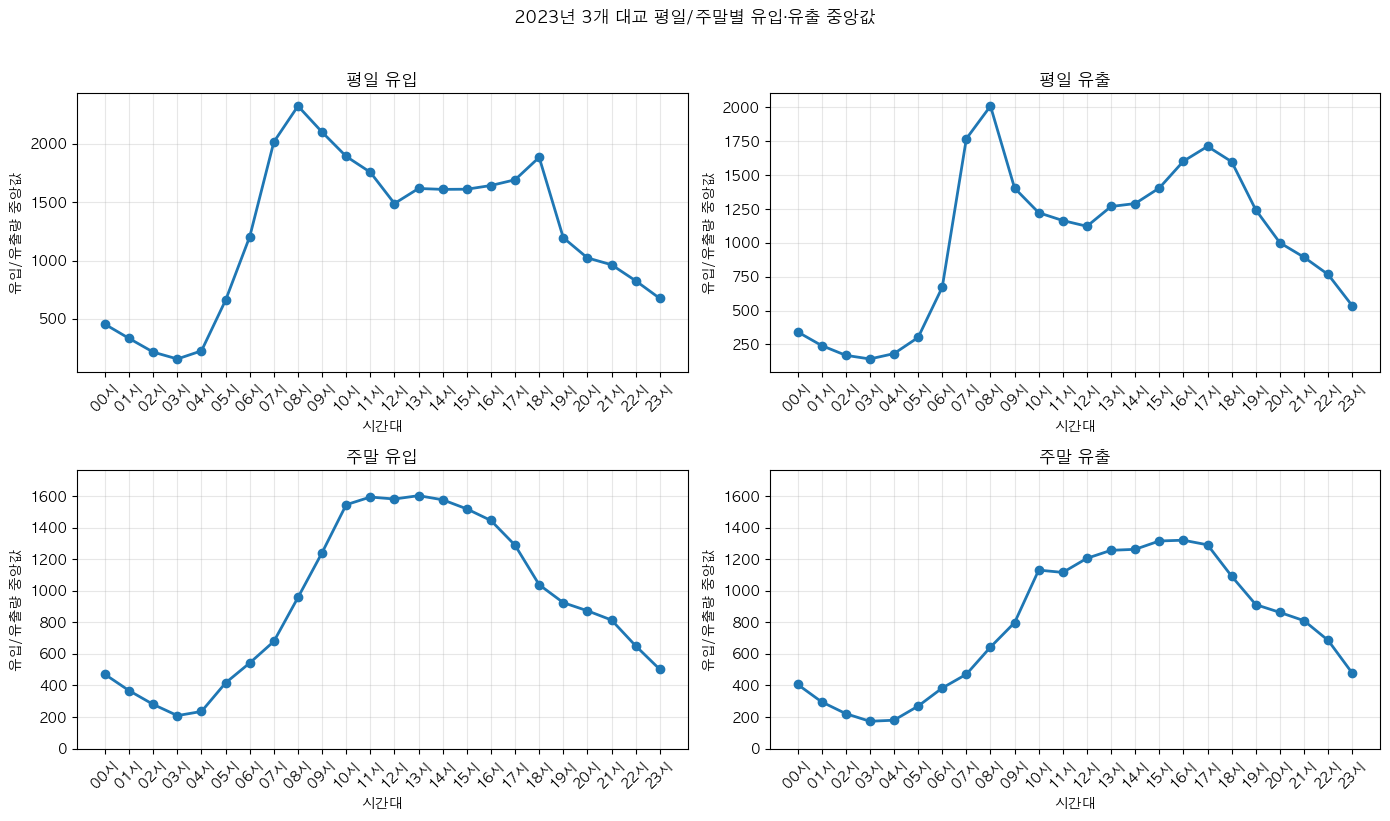

In [20]:
plot_order = [("평일", "유입"), ("평일", "유출"), ("주말", "유입"), ("주말", "유출")]
weekend_max = median_df[median_df["날짜타입"] == "주말"]["중앙값"].max()
weekend_ymax = weekend_max * 1.1 if pd.notna(weekend_max) else None

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)

for ax, (date_type, direction) in zip(axes.flatten(), plot_order):
    subset = median_df[(median_df["날짜타입"] == date_type) & (median_df["방향"] == direction)].sort_values("시간_순서")
    ax.plot(subset["시간_순서"], subset["중앙값"], marker="o", linewidth=2)
    ax.set_title(f"{date_type} {direction}")
    ax.set_xlabel("시간대")
    ax.set_ylabel("유입/유출량 중앙값")
    ax.set_xticks(range(24))
    ax.set_xticklabels([f"{hour:02d}시" for hour in range(24)], rotation=45)
    if date_type == "주말" and weekend_ymax is not None:
        ax.set_ylim(0, weekend_ymax)
    ax.grid(alpha=0.3)

fig.suptitle(f"{analysis_year}년 3개 대교 평일/주말별 유입·유출 중앙값", y=1.02)
fig.tight_layout()
plt.show()


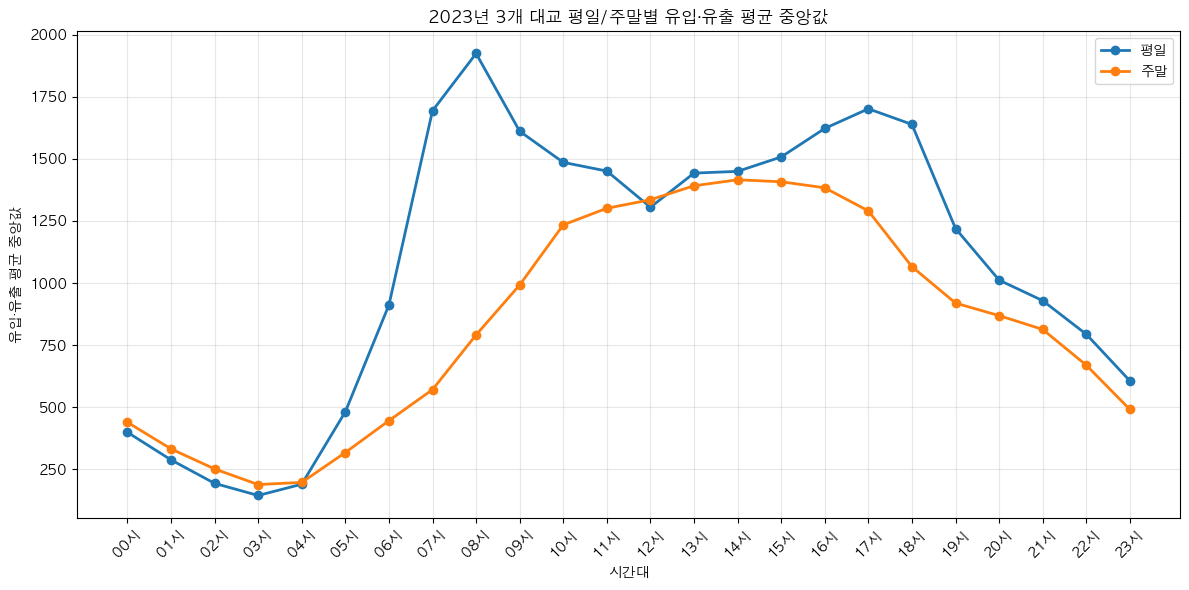

In [21]:
# Combined Weekday/Weekend Summary
combined_station_avg_df = (
    station_avg_df
    .groupby(["지점명", "날짜타입"], as_index=False)[hour_cols]
    .mean()
)

combined_median_df = combined_station_avg_df.melt(
    id_vars=["지점명", "날짜타입"],
    value_vars=hour_cols,
    var_name="시간",
    value_name="평균값",
)
combined_median_df["시간_순서"] = combined_median_df["시간"].str.extract(r"(\d+)").astype(int)
combined_median_df = (
    combined_median_df
    .groupby(["날짜타입", "시간", "시간_순서"], as_index=False)["평균값"]
    .median()
    .rename(columns={"평균값": "중앙값"})
    .sort_values(["날짜타입", "시간_순서"])
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(12, 6))
for date_type, color in [("평일", "#1f77b4"), ("주말", "#ff7f0e")]:
    subset = combined_median_df[combined_median_df["날짜타입"] == date_type].sort_values("시간_순서")
    ax.plot(subset["시간_순서"], subset["중앙값"], marker="o", linewidth=2, label=date_type, color=color)

ax.set_title(f"{analysis_year}년 3개 대교 평일/주말별 유입·유출 평균 중앙값")
ax.set_xlabel("시간대")
ax.set_ylabel("유입·유출 평균 중앙값")
ax.set_xticks(range(24))
ax.set_xticklabels([f"{hour:02d}시" for hour in range(24)], rotation=45)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
